In [5]:
from ucimlrepo import fetch_ucirepo
import jax
import jax.random as random
import jax.numpy as jnp

import numpyro
from numpyro import sample
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoDiagonalNormal
from numpyro import handlers


import matplotlib.pyplot as plt
import seaborn as sns

# Dataset

In [6]:
# fetch dataset 
concrete_compressive_strength = fetch_ucirepo(id=165) 
  
# data (as pandas dataframes) mcmc.get_samples()
X_df = concrete_compressive_strength.data.features
y_df = concrete_compressive_strength.data.target
X = jnp.array(X_df)
y = jnp.array(y_df)
  
# metadata 
print(concrete_compressive_strength.metadata) 
  
# variable information 
print(concrete_compressive_strength.variables) 

{'uci_id': 165, 'name': 'Concrete Compressive Strength', 'repository_url': 'https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength', 'data_url': 'https://archive.ics.uci.edu/static/public/165/data.csv', 'abstract': 'Concrete is the most important material in civil engineering. The concrete compressive strength is a highly nonlinear function of age and ingredients. ', 'area': 'Physics and Chemistry', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 1030, 'num_features': 8, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Concrete compressive strength'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sun Feb 11 2024', 'dataset_doi': '10.24432/C5PK67', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 383, 'type': 'NATIVE', 'title': 'Modeling of strength of high-performance concrete using artificial neural networks', 'authors': 'I. Yeh', 'venue': 'C

/tmp/ipykernel_12369/3824217163.py:8: FutureWarning: None encountered in jnp.array(); this is currently treated as NaN. In the future this will result in an error.
  y = jnp.array(y_df)


# Model definition, inference functions

In [7]:
def model(X, Y=None, D_H=2, D_Y=1):
    N, D_X = X.shape[-2], X.shape[-1]
    w1 = sample("w1", dist.Normal(jnp.zeros((D_X, D_H)), jnp.ones((D_X, D_H)))) # (D_X, D_H)
    z1 = jnp.tanh(X @ w1) # => (D_N, D_H)

    w2 = sample("w2", dist.Normal(jnp.zeros((D_H, D_Y)), jnp.ones((D_H, D_Y)))) # (D_X, D_H)
    z2 = z1 @ w2 # => (D_N, D_H)

    # w3 = sample("w3", dist.Normal(jnp.zeros((D_H, D_H)), jnp.ones((D_H, D_H)))) # (D_X, D_H)
    # z3 = jnp.tanh(z2 @ w3) # => (D_N, D_Y)

    # w4 = sample("w4", dist.Normal(jnp.zeros((D_H, D_H)), jnp.ones((D_H, D_H)))) # (D_X, D_H)
    # z4 = jnp.tanh(z3 @ w4) # => (D_N, D_Y)

    # w5 = sample("w5", dist.Normal(jnp.zeros((D_H, D_Y)), jnp.ones((D_H, D_Y)))) # (D_X, D_H)
    # z5 = jnp.tanh(z4 @ w5) # => (D_N, D_Y)

    precision_obs = sample("precision_obs", dist.Gamma(3.0,1.0))
    sigma_obs = 1/jnp.sqrt(precision_obs)
    with numpyro.plate("data", N):
        return sample("Y", dist.Normal(z2, sigma_obs).to_event(1), obs=Y)

In [8]:
# Infer posterior samples using NUTS 
def mcmc_inference(rng_key, model, num_samples, D_H=2, X=X, y=y) -> MCMC:
    kernel = NUTS(model)
    mcmc = MCMC(kernel, num_chains=1, num_samples=num_samples, num_warmup=100)
    mcmc.run(rng_key, X, y, D_H=D_H)
    mcmc.print_summary()
    return mcmc


def mcmc_predictions(rng_key, model, n_predictions, X_test, D_H=2, X=X, y=y):
    key1, key2 = random.split(rng_key, 2)
    mcmc = mcmc_inference(key1, model, n_predictions, D_H=D_H, X=X, y=y)
    posterior_samples = mcmc.get_samples()
    def predict(model, rng_key, samples, X, D_H):
        model = handlers.substitute(handlers.seed(model, rng_key), samples)
        model_trace = handlers.trace(model).get_trace(X=X, Y=None, D_H=D_H)
        return model_trace["Y"]["value"]
    predictions = jax.vmap(
        lambda samples, rng_key: predict(model, rng_key, samples, X_test, D_H)
    )(posterior_samples, random.split(key2, n_predictions))

    return predictions

def svi_predictions(rng_key, model, n_predictions, D_H=2, X=X, y=y):
    key1, key2 = random.split(rng_key, 2)
    guide = AutoDiagonalNormal(model)
    optimizer = numpyro.optim.Adam(step_size=5e-3)
    svi = SVI(model, guide, optimizer, Trace_ELBO())
    svi.run(key1, 100000, X, y, D_H=D_H)
    predictive = Predictive(model, guide=guide, batch_ndims=1, num_samples=n_predictions)
    samples = predictive(key2, X)
    return samples["Y"]

# Run inference

In [11]:
key = random.PRNGKey(123)
key, key_ = random.split(key, 2)
mcmc_samples = mcmc_predictions(key_, model, 100, X, D_H=50)
mcmc_samples

ValueError: Expected value.dim() >= 1 but got 0

In [4]:
key, key_ = random.split(key)
svi_samples = svi_predictions(key_, model, 100, D_H=50)
svi_samples

NameError: name 'svi_predictions' is not defined

In [90]:
print(mcmc_samples.shape, svi_samples.shape)

(100, 1030, 1) (100, 1030, 1)


# Plotting

KDE of posterior predictive samples

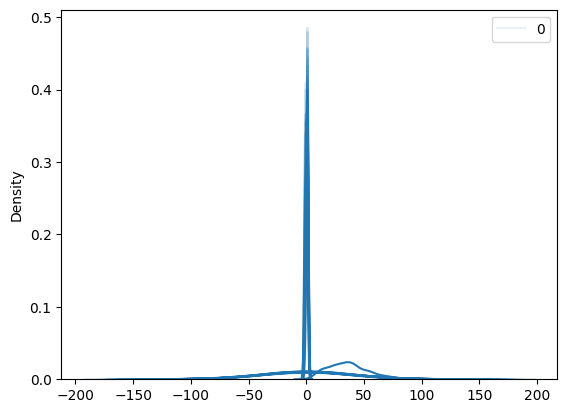

In [91]:
sns.set_palette("tab10")

sns.kdeplot(y)
for i in range(min(len(mcmc_samples), 100)):
    sns.kdeplot(mcmc_samples[i], alpha=0.1, color="orange")

for i in range(min(len(svi_samples), 100)):
    sns.kdeplot(svi_samples[i], alpha=0.1, color="green")

plt.show()

sample: 100%|██████████| 200/200 [00:09<00:00, 21.82it/s, 511 steps of size 8.06e-03. acc. prob=0.77]



                     mean       std    median      5.0%     95.0%     n_eff     r_hat
  precision_obs      4.33      0.21      4.34      3.95      4.65    153.24      1.00
        w1[0,0]     -0.15      1.11     -0.11     -1.77      1.66    109.58      0.99
        w1[0,1]     -0.04      1.10      0.06     -1.53      1.99     92.41      1.00
        w1[1,0]     -0.08      1.04     -0.10     -1.70      1.42     84.90      0.99
        w1[1,1]      0.01      0.84     -0.08     -1.29      1.28     88.48      0.99
        w1[2,0]     -0.01      0.99      0.04     -1.49      1.43    148.05      1.00
        w1[2,1]     -0.02      1.14      0.03     -1.56      1.97    101.74      1.01
        w1[3,0]      0.08      0.92      0.02     -1.20      1.63    104.22      0.99
        w1[3,1]      0.01      0.94      0.08     -1.32      1.24    102.68      1.00
        w1[4,0]     -0.09      0.92     -0.04     -1.58      1.37     98.38      0.99
        w1[4,1]      0.03      1.12     -0.11     -1.

ValueError: x and y must be the same size

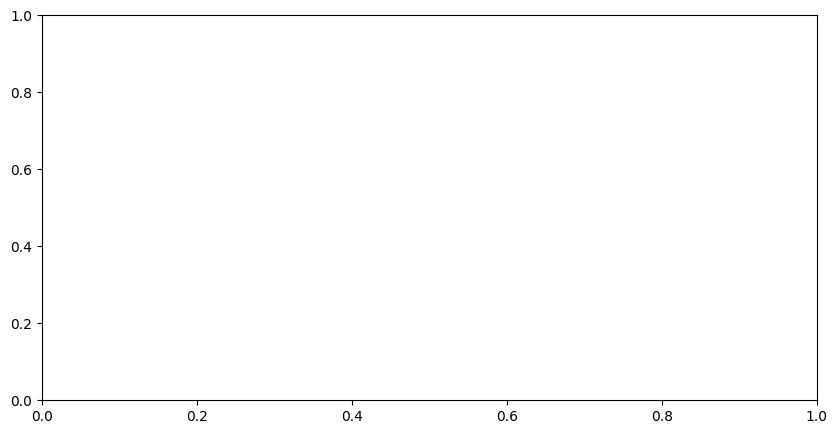

In [105]:
def evaluate_on_sim(key):
    key, key1, key2, key3 = random.split(key,4)
    x_obs = jnp.hstack([jnp.linspace(-0.2, 0.2, 500), jnp.linspace(0.6, 1, 500)])
    noise = 0.02 * random.normal(key1, x_obs.shape[0])
    y_obs = x_obs + 0.3 * jnp.sin(2 * jnp.pi * (x_obs + noise)) + 0.3 * jnp.sin(4 * jnp.pi * (x_obs + noise)) + noise

    x_true = jnp.linspace(-0.5, 1.5, 1000)
    y_true = x_true + 0.3 * jnp.sin(2 * jnp.pi * x_true) + 0.3 * jnp.sin(4 * jnp.pi * x_true)

    # Set plot limits and labels
    xlims = [-0.5, 1.5]
    ylims = [-1.5, 2.5]
    
    mcmc_samples = mcmc_predictions(key2, model, 100, jnp.array([x_true]), X=jnp.array([x_obs]), y=y_obs)
    #svi_samples = svi_predictions(key2, model, 100, 10, X=x_obs, y=y_obs)

    mean_prediction = jnp.mean(mcmc_samples, axis=0)

    # Create plot
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.scatter(x_obs, mean_prediction)

    ax.plot(x_true, y_true, 'b-', linewidth=3, label="True function")
    ax.plot(x_obs, y_obs, 'ko', markersize=4, label="Observations")
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    ax.set_xlabel("X", fontsize=10)
    ax.set_ylabel("Y", fontsize=10)
    ax.legend(loc=4, fontsize=15, frameon=False)

    plt.show()
key, key_ = random.split(key)
evaluate_on_sim(key_)